In [1]:
!git clone https://github.com/valeriouberti/webcam-object-recognition.git
%cd /content/webcam-object-recognition
!ls -lh

Cloning into 'webcam-object-recognition'...
remote: Enumerating objects: 11, done.
remote: Total 11 (delta 0), reused 0 (delta 0), pack-reused 11 (from 1)
Receiving objects: 100% (11/11), 5.36 MiB | 35.17 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/webcam-object-recognition
total 12K
-rw-r--r-- 1 root root 1.3K Sep  7 06:30 main.py
drwxr-xr-x 2 root root 4.0K Sep  7 06:30 models
-rw-r--r-- 1 root root 1.6K Sep  7 06:30 README.md


In [2]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 6.2 MB/s eta 0:00:00


In [3]:
import torch
from ultralytics import YOLO

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

model = YOLO("/content/webcam-object-recognition/models/yolo11n.pt")
print("YOLOv11 model loaded successfully.")
print("Number of classes:", len(model.names))

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
GPU available: True
GPU name: Tesla T4
YOLOv11 model loaded successfully.
Number of classes: 80


Number of test images: 9

0: 640x640 1 vase, 5.1ms
1: 640x640 1 cup, 1 keyboard, 5.1ms
2: 640x640 1 knife, 1 cell phone, 5.1ms
3: 640x640 1 cup, 1 tv, 1 book, 5.1ms
4: 640x640 1 toothbrush, 5.1ms
5: 640x640 1 bear, 5.1ms
6: 640x640 2 bottles, 1 dining table, 2 keyboards, 1 cell phone, 5.1ms
7: 640x640 1 knife, 1 scissors, 5.1ms
8: 640x640 (no detections), 5.1ms
Speed: 12.0ms preprocess, 5.1ms inference, 5.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/webcam-object-recognition/results/baseline


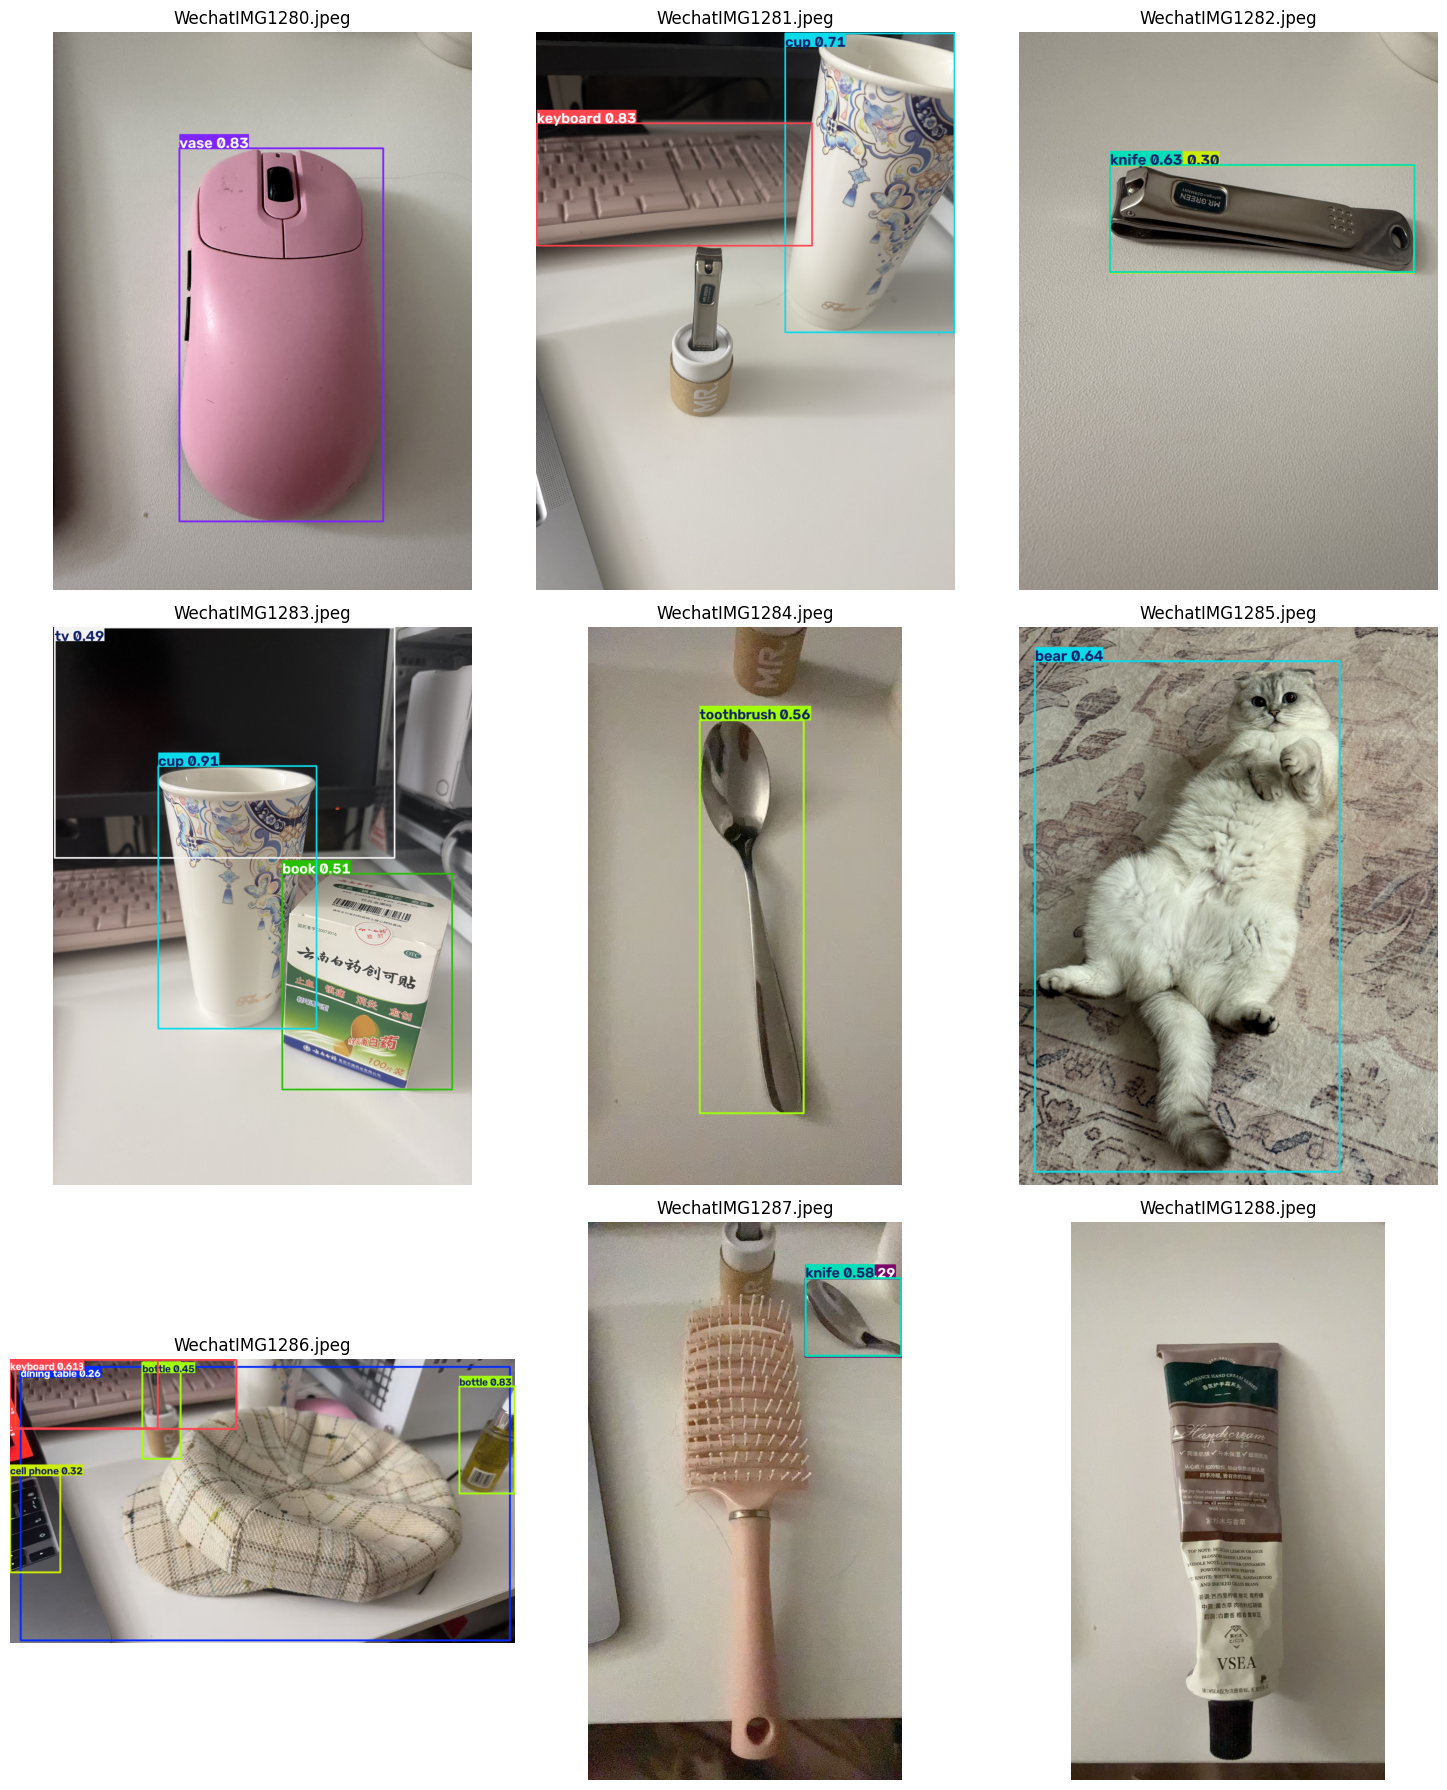

In [4]:
import glob
import os
import matplotlib.pyplot as plt

image_paths = sorted(glob.glob("/content/WechatIMG*.jpeg"))
print("Number of test images:", len(image_paths))

results = model.predict(
    source=image_paths,
    conf=0.25,
    save=True,
    project="/content/webcam-object-recognition/results",
    name="baseline",
    exist_ok=True,
    device=0
)

fig, axes = plt.subplots(3, 3, figsize=(15, 18))

for ax, result, image_path in zip(axes.flat, results, image_paths):
    plotted_image = result.plot()
    ax.imshow(plotted_image[:, :, ::-1])
    ax.set_title(os.path.basename(image_path))
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path
from google.colab import files
import pandas as pd
import shutil

experiment_dir = Path("/content/webcam-object-recognition/experiment1")
input_dir = experiment_dir / "input_images"
output_dir = experiment_dir / "baseline_results"

input_dir.mkdir(parents=True, exist_ok=True)
output_dir.mkdir(parents=True, exist_ok=True)

for image_path in image_paths:
    shutil.copy2(image_path, input_dir / Path(image_path).name)

for result in results:
    result.save(filename=str(output_dir / Path(result.path).name))

rows = []

for image_path, result in zip(image_paths, results):
    if len(result.boxes) == 0:
        rows.append({
            "image": Path(image_path).name,
            "predicted_class": "No detection",
            "confidence": None
        })
    else:
        for class_id, confidence in zip(
            result.boxes.cls.cpu().tolist(),
            result.boxes.conf.cpu().tolist()
        ):
            rows.append({
                "image": Path(image_path).name,
                "predicted_class": result.names[int(class_id)],
                "confidence": round(confidence, 3)
            })

summary = pd.DataFrame(rows)
summary.to_csv(experiment_dir / "baseline_predictions.csv", index=False)
display(summary)

shutil.make_archive(
    "/content/experiment1_baseline",
    "zip",
    root_dir=experiment_dir
)

files.download("/content/experiment1_baseline.zip")

,image,predicted_class,confidence
0,WechatIMG1280.jpeg,vase,0.829
1,WechatIMG1281.jpeg,keyboard,0.835
2,WechatIMG1281.jpeg,cup,0.711
3,WechatIMG1282.jpeg,knife,0.630
4,WechatIMG1282.jpeg,cell phone,0.305
5,WechatIMG1283.jpeg,cup,0.915
6,WechatIMG1283.jpeg,book,0.507
7,WechatIMG1283.jpeg,tv,0.491
8,WechatIMG1284.jpeg,toothbrush,0.563
9,WechatIMG1285.jpeg,bear,0.640


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>